## What is a Molecular Fingerprint?

A molecular fingerprint is a numerical representation of a molecule's structural features.

Instead of describing physical properties (like molecular descriptors), fingerprints encode the presence or absence of structural fragments.

These fingerprints are typically represented as a binary vector consisting of 0s and 1s.

Each position (bit) represents a specific structural feature:

- 1 → Feature is present
- 0 → Feature is absent

## Why Do We Need Molecular Fingerprints?

Computers cannot compare molecular structures the way chemists do.

A medicinal chemist can quickly recognize that two molecules have similar structures.

However, a computer only sees atoms and bonds.

To efficiently compare millions of molecules, chemical structures must be converted into a machine-readable representation.

One of the most widely used representations is the molecular fingerprint.

## Descriptors vs Fingerprints

Although both descriptors and fingerprints convert molecules into numerical representations, they serve different purposes.

Descriptors describe molecular properties.

Examples:

- Molecular Weight
- LogP
- TPSA

Fingerprints describe molecular structure.

Examples:

- Presence of aromatic rings
- Presence of carbonyl groups
- Presence of specific atom neighborhoods

Think of it this way:

Descriptors answer:

"What are the properties of this molecule?"

Fingerprints answer:

"What structural features does this molecule contain?"

## Types of Molecular Fingerprints

Different fingerprint algorithms capture different aspects of a molecule's structure.

Each fingerprint is designed for specific cheminformatics applications such as similarity searching, virtual screening, clustering, or machine learning.

The most commonly used fingerprint types are:

In this RDKit roadmap, we will mainly focus on:

- Morgan Fingerprints (Most Important)
- MACCS Keys
- RDKit (Path-Based) Fingerprints

These are the fingerprint types most commonly used in cheminformatics research and pharmaceutical industries.

## How Are Molecular Fingerprints Generated?

A molecular fingerprint is not created manually.

Instead, a fingerprint algorithm examines the molecular structure and identifies important structural features.

The algorithm then converts these features into a binary vector consisting of 0s and 1s.

Each bit represents the presence or absence of a particular structural feature.

1 → Feature Present

0 → Feature Absent

In [1]:
# Example 
# fingerprints of paracetamol using RDKit
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# SMILES for Paracetamol
smiles = "CC(=O)NC1=CC=C(C=C1)O"

# Convert SMILES to RDKit molecule
mol = Chem.MolFromSmiles(smiles)

In [2]:
# Create Morgan Fingerprint Generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

# Generate fingerprint
fingerprint = morgan_gen.GetFingerprint(mol)

In [3]:
print(fingerprint)

In [4]:
# Convert fingerprint into Binary Bits
bit_string = fingerprint.ToBitString()

print(bit_string)

0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000001000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

The complete fingerprint contains 2048 binary digits (bits).

In [5]:
print("Fingerprint Length:", len(bit_string))
print("Number of Active Bits:", bit_string.count("1"))

Fingerprint Length: 2048
Number of Active Bits: 20


### Understanding the Output

The Morgan fingerprint generated above consists of 2048 bits.

Each bit corresponds to a hashed structural environment detected within the molecule.

Bit value:

- 1 → A particular structural feature is present.
- 0 → That structural feature is absent.

Unlike MACCS Keys, the bit positions in a Morgan fingerprint do not correspond to predefined functional groups. Instead, they are generated using a hashing algorithm based on the local atomic environments surrounding each atom.

# Visualization for Advance Understandig how Morgan Fingerprint are actually constructed

In [6]:
# Visualizing Which Atoms Generated Each Morgan Fingerprint Bit 
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole

# Show atom indices
IPythonConsole.drawOptions.addAtomIndices = True

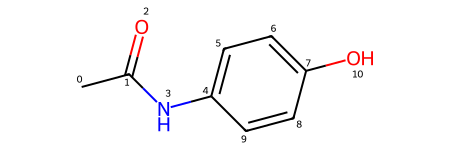

In [7]:
smiles = "CC(=O)NC1=CC=C(C=C1)O"

mol = Chem.MolFromSmiles(smiles)

mol

In [8]:
from rdkit.Chem.rdFingerprintGenerator import AdditionalOutput

ao = AdditionalOutput()

# Store which atoms generated each bit
ao.AllocateBitInfoMap()

In [9]:
generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fp = generator.GetFingerprint(
    mol,
    additionalOutput=ao
)

In [10]:
bit_info = ao.GetBitInfoMap()

print(bit_info)

{191: ((4, 1),), 245: ((1, 1),), 530: ((3, 2),), 650: ((2, 0),), 745: ((7, 1),), 807: ((1, 0), (10, 0)), 843: ((5, 2), (9, 2)), 849: ((1, 2),), 1017: ((0, 1),), 1057: ((0, 0),), 1077: ((4, 2),), 1152: ((3, 0),), 1313: ((6, 2), (8, 2)), 1380: ((4, 0), (7, 0)), 1602: ((10, 1),), 1750: ((5, 1), (6, 1), (8, 1), (9, 1)), 1778: ((7, 2),), 1816: ((3, 1),), 1873: ((5, 0), (6, 0), (8, 0), (9, 0)), 1917: ((2, 1),)}


In [11]:
for bit, info in bit_info.items():
    print(f"Bit {bit}: {info}")

Bit 191: ((4, 1),)
Bit 245: ((1, 1),)
Bit 530: ((3, 2),)
Bit 650: ((2, 0),)
Bit 745: ((7, 1),)
Bit 807: ((1, 0), (10, 0))
Bit 843: ((5, 2), (9, 2))
Bit 849: ((1, 2),)
Bit 1017: ((0, 1),)
Bit 1057: ((0, 0),)
Bit 1077: ((4, 2),)
Bit 1152: ((3, 0),)
Bit 1313: ((6, 2), (8, 2))
Bit 1380: ((4, 0), (7, 0))
Bit 1602: ((10, 1),)
Bit 1750: ((5, 1), (6, 1), (8, 1), (9, 1))
Bit 1778: ((7, 2),)
Bit 1816: ((3, 1),)
Bit 1873: ((5, 0), (6, 0), (8, 0), (9, 0))
Bit 1917: ((2, 1),)
